# 1.

#### The key factor that determines the difference between ideas that can, and cannnot be examined and tested statistically is the presence of an objective quantitative measure that either clearly supports or rejects the given idea when evaluated on a single statisitc. A good null hypothesis would be one which is expressed in precise terms such that any individual statistic can be undoubtedly evaluated as either rejecting or not rejecting the null hypothesis. An alternative hypothesis is the hypothesis that must be accepted if the assumed null hypothesis is rejected and as such, the two are mutually exclusive.

# 2.

#### The goal of statistics is to make inferences about a population based on sampled data from the population. Thus hypothesis testing for a given parameter, e.g. the population mean, evaluates the degree to which that parameter computed on a given set of sampled data points (e.g. the sample mean) is representative of the population parameter, i.e. the parameter when inferred from all data points in the population, and thus we can ascertain with what confidence the null hypothesis (which is the default presumption about the value of the population parameter, e.g. the population mean) can be rejected (or not rejected).

# 3.

#### The p-value is a measure of the probability that a statistic is as or more extreme than the observed statistic if the null hypothesis is true. Thus we imagine a hypothetical world in which the null hypothesis is true, and then we check the probability that one of the datapoints in the distribution is the same as the statistic. If the probability is high, this means that there is a high likelihood that the population this statistic was sampled from does not reject the null hypothesis, and there is thus a higher correlation between the hypothetical world and the population.

# 4.

#### A smaller p-value makes the null hypothesis look more ridiculous because it means that the 'hypothetical world' in which the null hypothesis is true has a lower probability of containing a statistic that is the same as the sample statistic. Thus to assume that the population distribution from which this  statisitic came from is representative of a population in which the null hypothesis is not rejected becomes less probable, to the point where it makes sense to assume that the population distribution rejects the null hypothesis.

# 5.

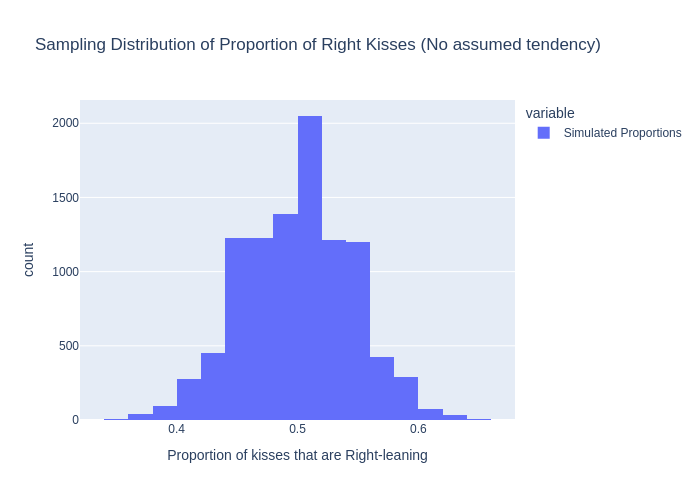

In [2]:
#NOTE: Template borrowed from Prof. Schwartz's textbook

import numpy as np
from scipy import stats
import plotly.express as px

n_kisses_per_sample = 124
n_sample_simulations = 10000
simulated_proportion_kisses_right = np.zeros(n_sample_simulations)
H0_p = 0.5

for i in range(n_sample_simulations):
    n_kisses = np.random.choice(['right','left'], p=[H0_p,1-H0_p], size=n_kisses_per_sample)
    simulated_proportion_kisses_right[i] = (n_kisses=='right').mean()

fig = px.histogram(simulated_proportion_kisses_right, nbins=30, 
                   title='Sampling Distribution of Proportion of Right Kisses (No assumed tendency)',
                   labels={'value': 'Proportion of kisses that are Right-leaning', 'count': 'Frequency'})
fig.update_traces(name='Simulated Proportions')
fig.show(renderer='png')

If we observed a proportion of 0.645 right-leaning kisses out of 124 kisses
The (p-value) chance that we would get a proportion (statistic)
further from 50/50 ("as or more extreme") than the proportion of
right-leaning kisses we saw (observed statistic) if their was no natural tendecy towards either side (H0 is true)
would be 0.0015 which we estimated using 10000 simulations of 124 kisses
as illustrated below


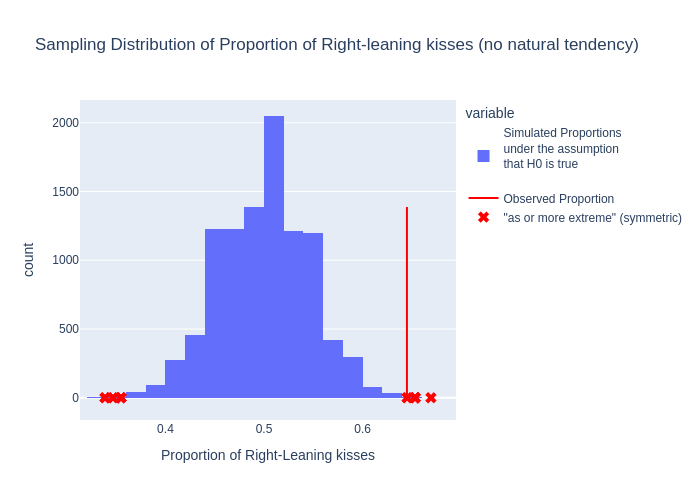

In [3]:
import plotly.graph_objects as go

observed_proportion_statistic = 0.645
print("If we observed a proportion of", observed_proportion_statistic, "right-leaning kisses out of", n_kisses_per_sample, "kisses")
print("The (p-value) chance that we would get a proportion (statistic)")
print('further from 50/50 ("as or more extreme") than the proportion of')
print("right-leaning kisses we saw (observed statistic) if their was no natural tendecy towards either side (H0 is true)")
as_or_more_extreme = abs(simulated_proportion_kisses_right - H0_p) >= abs(observed_proportion_statistic - H0_p)
print("would be", as_or_more_extreme.sum()/n_sample_simulations, "which we estimated using", n_sample_simulations, "simulations of", n_kisses_per_sample, "kisses")
print("as illustrated below")

fig = px.histogram(simulated_proportion_kisses_right, nbins=30, 
                   title='Sampling Distribution of Proportion of Right-leaning kisses (no natural tendency)',
                   labels={'value': 'Proportion of Right-Leaning kisses', 'count': 'Frequency'})
fig.update_traces(name='Simulated Proportions<br>under the assumption<br>that H0 is true<br>')

# Add vertical line for observed proportion
fig.add_trace(go.Scatter(x=[observed_proportion_statistic] * 2,
                         y=[0, max(np.histogram(simulated_proportion_kisses_right, bins=30)[0])],
              mode='lines', line=dict(color='red', width=2), name='Observed Proportion'))

# Mark the p-value area
x_as_or_more_extreme = simulated_proportion_kisses_right[as_or_more_extreme]
fig.add_trace(go.Scatter(x=x_as_or_more_extreme, y=0*x_as_or_more_extreme,
    mode='markers', marker=dict(color='red', size=10, symbol='x'),
    name='"as or more extreme" (symmetric)'))
fig.show(renderer='png')

With a p-value of 0.0019, string evidence against the null hypothesis

In [4]:
#OR a more concise NotebookLM-generated method

import numpy as np

# Set the seed for reproducibility
np.random.seed(123)

# Define the parameters
n_couples = 124  # Sample size
n_simulations = 10000  # Number of simulations

# Create an array to store the proportions of right tilts in each simulation
right_tilt_proportions = np.empty(n_simulations)

# Run the simulations
for i in range(n_simulations):
  # Simulate 124 coin flips
  flips = np.random.choice(['right', 'left'], size=n_couples)
  
  # Calculate the proportion of right tilts in the current simulation
  right_tilt_proportions[i] = np.sum(flips == 'right') / n_couples

# Calculate the p-value
observed_proportion = 0.645  # Observed proportion from the study
p_value = np.sum(right_tilt_proportions >= observed_proportion) / n_simulations

# Print the simulated p-value
print("Simulated p-value:", p_value)

Simulated p-value: 0.0013


# 6.

#### No, we cannot definitely prove that the null hypothesis is false. The very nature of a p-value is a PROBABILITY, i.e. a certain chance that the observed statistic comes from a sample distribution in which the null hypothesis is true  (If we theoretically had a population size of 1 and sampled from it, we could reject or not reject the null hypothesis in a definitive manner). We could thus not prove definitely that Fido is guilty (for the most absurd of possibilities, however small their likelihood, one can always conjure  a scenario that allow a small chance for the observation we make of Fido (the garbage lid around his neck) to have been drawn from a population of datapoints in which Fido is not guilty). By the same token, the converse is also true.

# 7.

In [5]:
import pandas as pd
import plotly.graph_objs as go
import plotly.figure_factory as ff


patient_data = pd.DataFrame({
    "PatientID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Age": [45, 34, 29, 52, 37, 41, 33, 48, 26, 39],
    "Gender": ["M", "F", "M", "F", "M", "F", "M", "F", "M", "F"],
    "InitialHealthScore": [84, 78, 83, 81, 81, 80, 79, 85, 76, 83],
    "FinalHealthScore": [86, 86, 80, 86, 84, 86, 86, 82, 83, 84]
})
patient_data['HealthScoreChange'] = patient_data.FinalHealthScore-patient_data.InitialHealthScore
patient_data

,PatientID,Age,Gender,InitialHealthScore,FinalHealthScore,HealthScoreChange
0,1,45,M,84,86,2
1,2,34,F,78,86,8
2,3,29,M,83,80,-3
3,4,52,F,81,86,5
4,5,37,M,81,84,3
5,6,41,F,80,86,6
6,7,33,M,79,86,7
7,8,48,F,85,82,-3
8,9,26,M,76,83,7
9,10,39,F,83,84,1


In [8]:
np.random.seed(1)  # make simulation reproducible
number_of_simulations = 10000  # experiment with this... what does this do?
n_size = len(patient_data)  # 10
IncreaseProportionSimulations_underH0random = np.zeros(number_of_simulations)

# generate "random improvement" proportions assuming H0 (vaccine has no average effect) is true 
# meaning that the "before and after" differences are positive or negative at "random"
for i in range(number_of_simulations):
    
    # why is this equivalent to the suggested idea above?
    random_improvement = np.random.choice([0,1], size=len(patient_data), replace=True)  # <<< `replace=True` ^^^

    # why is .mean() a proportion? 
    IncreaseProportionSimulations_underH0random[i] = random_improvement.mean()

In [9]:
# Calculate the p-value
# How many bootstrapped statistics generated under H0 
# are "as or more extreme" than the observed statistic 
# (relative to the hypothesized population parameter)? 

population_parameter_value_under_H0 = 0.5
observed_statistic = (patient_data.HealthScoreChange>0).mean()
simulated_statistics = IncreaseProportionSimulations_underH0random

# Be careful with "as or more extreme" as it's symmetric!
SimStats_as_or_more_extreme_than_ObsStat = \
    abs(simulated_statistics - population_parameter_value_under_H0) >= \
    abs(observed_statistic - population_parameter_value_under_H0)
    
p_value = (SimStats_as_or_more_extreme_than_ObsStat).sum() / number_of_simulations
print("Number of Simulations: ", number_of_simulations, "\n\n",
      "Number of simulated statistics (under HO)\n",
      'that are "as or more extreme" than the observed statistic: ',
      SimStats_as_or_more_extreme_than_ObsStat.sum(), "\n\n",
      'p-value\n(= simulations "as or more extreme" / total simulations): ', p_value, sep="")

Number of Simulations: 10000

Number of simulated statistics (under HO)
that are "as or more extreme" than the observed statistic: 680

p-value
(= simulations "as or more extreme" / total simulations): 0.068


In [12]:
# Calculate the p-value
# How many bootstrapped statistics generated under H0 
# are "as or more extreme" than the observed statistic 
# (relative to the hypothesized population parameter)? 

population_parameter_value_under_H0 = 0.5
observed_statistic = (patient_data.HealthScoreChange>0).mean()
simulated_statistics = IncreaseProportionSimulations_underH0random

# Be careful with "as or more extreme" as it's symmetric!
SimStats_as_or_more_extreme_than_ObsStat = simulated_statistics >= observed_statistic
    
p_value = (SimStats_as_or_more_extreme_than_ObsStat).sum() / number_of_simulations
print("Number of Simulations: ", number_of_simulations, "\n\n",
      "Number of simulated statistics (under HO)\n",
      'that are "as or more extreme" than the observed statistic: ',
      SimStats_as_or_more_extreme_than_ObsStat.sum(), "\n\n",
      'p-value\n(= simulations "as or more extreme" / total simulations): ', p_value, sep="")

Number of Simulations: 10000

Number of simulated statistics (under HO)
that are "as or more extreme" than the observed statistic: 565

p-value
(= simulations "as or more extreme" / total simulations): 0.0565


### This one sided test tests whether or not we can reject a null hypothesis of the vaccine that the health improvement is less than or equal to 0.5 (the vaccine has adverse or no effects). The code changed was the calculation of ''' SimStats_as_or_more_extreme_than_ObsStat = simulated_statistics >= observed_statistic '''. It is logical to expect a p-value that is smaller because only one 'type of deviation' is being examined, and therefore more of sampled observations will fail to reject the null hypothesis.


# 8.

#### Relationship between the STA130 experiment and the Original: Whereas Fisher had exposure to both variations of the tea-milk order, each student has one cup of tea to try from, which at random may be either milk or tea, with no reference against which to ascertain the milk-tea order of the cup at hand (as a result, the expected p-value should be lower). Furthermore, Fisher is far more experienced in potential nuances of tea taste due to her daily exposure, which is probably far from the case in the STA130 sample size. The students are probably more representative of the general population of liquid-consumers. Lastly, the sample size of STA130 students is much large. H

#### Null Hypothesis: H0: p=0.5 (p is the proportion of students who correctly identify order, i.e. students identify the correct order by chance]). Informally, the student's guess is not an educated one but rather done purely at random (i.e. it is not possible to ascertain the order by tasting the cup)

#### Alternative Hypothesis: HA: p =/= 0.5. Informally, the student's guess is not purely random, and the taste of the cup influences the choice of order


### Quantitative Analysis:
Population: All possible STA130 students
Sample: 80 students
Parameter of interset: Proporition of students who can correctly ascertain order
#### Observed Test Statistic:
Correct guesses: 49
Sample size: 80
    Observed proportion: 49/80=0.6125


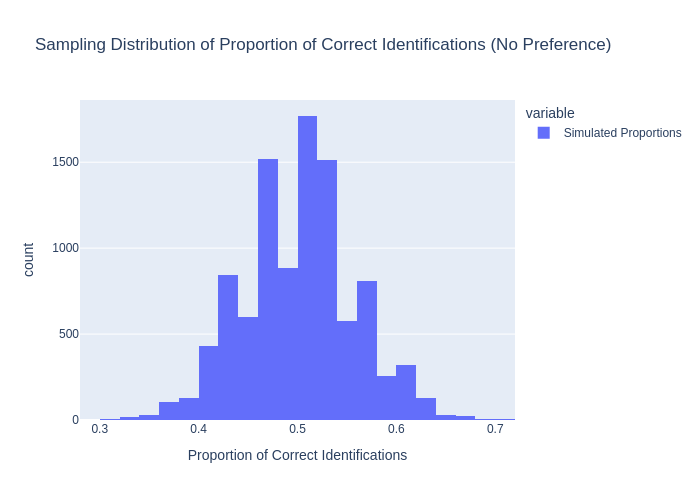

In [13]:
import numpy as np
from scipy import stats
import plotly.express as px

# Parameters for the STA130 tea experiment
n_students = 80  # Sample size (students tasting tea)
n_sample_simulations = 10000  # Number of simulations
simulated_proportion_correct = np.zeros(n_sample_simulations)  # Store simulated proportions
H0_p = 0.5  # Null hypothesis probability of correctly identifying

# Simulating the distribution of correct identifications under H0
for i in range(n_sample_simulations):
    # Simulate responses assuming no preference (random guessing)
    n_identifications = np.random.choice(['correct', 'incorrect'], p=[H0_p, 1-H0_p], size=n_students)
    simulated_proportion_correct[i] = (n_identifications == 'correct').mean()  # Calculate the proportion of correct responses

# Create a histogram of the simulated proportions
fig = px.histogram(simulated_proportion_correct, nbins=30, 
                   title='Sampling Distribution of Proportion of Correct Identifications (No Preference)',
                   labels={'value': 'Proportion of Correct Identifications', 'count': 'Frequency'})
fig.update_traces(name='Simulated Proportions')
fig.show(renderer='png')


If we observed a proportion of 0.6125 correct identifications out of 80 students
The (p-value) chance that we would get a proportion (statistic)
further from 50/50 ("as or more extreme") than the proportion of
correct identifications we saw (observed statistic) if there was no preference (H0 is true)
would be 0.0487 which we estimated using 10000 simulations of 80 students
as illustrated below


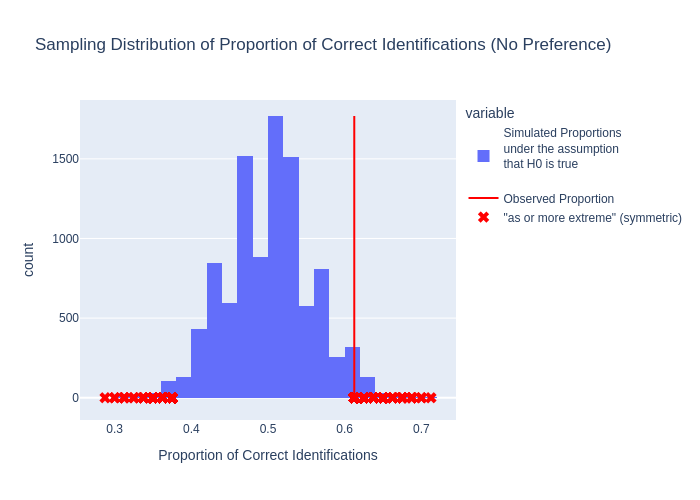

In [14]:
import plotly.graph_objects as go

# Observed proportion of students correctly identifying
observed_proportion_statistic = 49 / 80  # 49 out of 80 students
n_students = 80  # Total sample size (students)

print("If we observed a proportion of", observed_proportion_statistic, "correct identifications out of", n_students, "students")
print("The (p-value) chance that we would get a proportion (statistic)")
print('further from 50/50 ("as or more extreme") than the proportion of')
print("correct identifications we saw (observed statistic) if there was no preference (H0 is true)")
as_or_more_extreme = abs(simulated_proportion_correct - H0_p) >= abs(observed_proportion_statistic - H0_p)
p_value = as_or_more_extreme.sum() / n_sample_simulations
print("would be", p_value, "which we estimated using", n_sample_simulations, "simulations of", n_students, "students")
print("as illustrated below")

# Create histogram for the simulated proportions
fig = px.histogram(simulated_proportion_correct, nbins=30, 
                   title='Sampling Distribution of Proportion of Correct Identifications (No Preference)',
                   labels={'value': 'Proportion of Correct Identifications', 'count': 'Frequency'})
fig.update_traces(name='Simulated Proportions<br>under the assumption<br>that H0 is true<br>')

# Add vertical line for observed proportion
fig.add_trace(go.Scatter(x=[observed_proportion_statistic] * 2,
                         y=[0, max(np.histogram(simulated_proportion_correct, bins=30)[0])],
              mode='lines', line=dict(color='red', width=2), name='Observed Proportion'))

# Mark the p-value area (red markers for "as or more extreme")
x_as_or_more_extreme = simulated_proportion_correct[as_or_more_extreme]
fig.add_trace(go.Scatter(x=x_as_or_more_extreme, y=0*x_as_or_more_extreme,
    mode='markers', marker=dict(color='red', size=10, symbol='x'),
    name='"as or more extreme" (symmetric)'))

# Show the figure
fig.show(renderer='png')


In [15]:
import numpy as np

# Set the seed for reproducibility
np.random.seed(123)

# Define the parameters
n_students = 80  # Sample size
n_simulations = 10000  # Number of simulations

# Create an array to store the proportions of correct identifications in each simulation
correct_identification_proportions = np.empty(n_simulations)

# Run the simulations
for i in range(n_simulations):
    # Simulate 80 responses where students randomly guess 'milk' or 'tea'
    responses = np.random.choice(['milk', 'tea'], size=n_students)
    
    # Calculate the proportion of correct identifications in the current simulation
    correct_identification_proportions[i] = np.sum(responses == 'milk') / n_students

# Calculate the observed proportion of correct identifications
observed_proportion = 49 / n_students  # 49 out of 80 students
# Calculate the p-value
as_or_more_extreme = np.abs(correct_identification_proportions - 0.5) >= np.abs(observed_proportion - 0.5)
p_value = np.sum(as_or_more_extreme) / n_simulations

# Print the simulated p-value
print("Simulated p-value:", p_value)


Simulated p-value: 0.0286


The probability that the observed statistic (i.e. the STA130 trial of 80 students) has been drawn from a population where the null hypothesis is not to be rejected (i.e. the group of students has been drawn from a STA130 class with an overall tea-order-ascertaining ability that does not consist purely of random guessing) is 2.86%. Per the significance levels specified in the HW handout, there is moderate evidence against rejecting the null hypothesis, or concluding that the cup-order-ascertaining ability of STA130 students is not just random guessing.

# 9.

#### Yes